In [ ]:
pip install tensorflow

In [ ]:
pip install scikit-learn

1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from keras.optimizers import Adam

2. Load Dataset

In [ ]:
load_data= '\Data Cuaca\datacuaca.csv'

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1643/2813344023.py:1: SyntaxWarning: invalid escape sequence '\D'
  load_data= '\Data Cuaca\datacuaca.csv'


3. Membaca Dataset

In [ ]:
data = pd.read_csv('datacuaca.csv')  # Ubah 'nama_dataset.csv' sesuai dengan nama file dataset Anda

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


4. Menampilkan Dataset

In [ ]:
print(data)
data.info()

            Date    Tn    Tx    RR
0     2018-01-01  24.8  29.4  49.3
1     2018-01-02  23.6  30.7  61.0
2     2018-01-03  23.3  30.5  52.3
3     2018-01-04  22.0  30.1  16.7
4     2018-01-05  22.5  29.2  76.6
...          ...   ...   ...   ...
2217  2024-01-27  25.1  30.2   0.2
2218  2024-01-28  23.8  29.7  56.8
2219  2024-01-29  24.0  30.6  62.6
2220  2024-01-30  24.8  31.2   1.8
2221  2024-01-31  24.1  30.7   6.6

[2222 rows x 4 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2222 entries, 0 to 2221
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2222 non-null   object 
 1   Tn      2222 non-null   float64
 2   Tx      2222 non-null   float64
 3   RR      2222 non-null   float64
dtypes: float64(3), object(1)
memory usage: 69.6+ KB


5. Persiapan data LSTM

In [ ]:
# 2. Persiapan Data untuk Model LSTM
# Pisahkan fitur (features) dan label (labels)
features = data[['Tn', 'Tx', 'RR']]
labels = data[['Tn', 'Tx', 'RR']]

 6. Pisahkan data menjadi data latih dan data uji

In [ ]:
# Pisahkan data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

7. Pemodelan dengan LSTM menggunakan TensorFlow

In [ ]:
# 3. Pemodelan dengan LSTM menggunakan TensorFlow
# Tentukan jumlah time steps (jumlah langkah waktu) dan jumlah fitur
n_timesteps = 1  # Untuk keperluan contoh sederhana, kita akan menggunakan 1 time step
n_features = 3    # Jumlah fitur: temperatur minimum, temperatur maksimum, dan curah hujan

8. Tentukan model LSTM itu sendiri

In [ ]:
# Tentukan model LSTM
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(units=50, activation='relu', return_sequences=True, input_shape=(n_timesteps, n_features)),
    tf.keras.layers.LSTM(units=50, activation='relu'),
    tf.keras.layers.Dense(units=3)  # Output layer dengan 3 neuron untuk tiga parameter cuaca
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9. Kompilasi model LSTM

In [ ]:
# Kompilasi model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse')

In [ ]:
# Reshape data for LSTM
X_train_reshaped = X_train.values.reshape(-1, n_timesteps, n_features)
X_test_reshaped = X_test.values.reshape(-1, n_timesteps, n_features)

10. Melatih model dengan data yang ada

In [ ]:
# 4. Pelatihan Model
# Latih model
history = model.fit(X_train.values.reshape(-1, n_timesteps, n_features), y_train, epochs=300,
                    batch_size=32, validation_data=(X_test.values.reshape(-1, n_timesteps, n_features), y_test))

Epoch 1/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 440075.0938 - val_loss: 460845.0312
Epoch 2/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 265817.6562 - val_loss: 117400.1562
Epoch 3/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 27309.3457 - val_loss: 37.1884
Epoch 4/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 63.6530 - val_loss: 7.4415
Epoch 5/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.7696 - val_loss: 1.8287
Epoch 6/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3391 - val_loss: 1.6352
Epoch 7/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2446 - val_loss: 1.6006
Epoch 8/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2099 - val_loss: 1.4951
Epoch 9/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1837 - val_loss: 1.6026
Epoch 10/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1601 - val_loss: 1.6182
Epoch 11/300
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1392 - val_loss: 1.4955
Epoch 12/300
56/56 ━━━━━━━━━━━━━━━━

11. Evaluasi model AI yang ada

In [ ]:
# 5. Evaluasi Model
# Evaluasi model
loss = model.evaluate(X_test.values.reshape(-1, n_timesteps, n_features), y_test)
print("Mean Squared Error (MSE):", loss)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.2133 
Mean Squared Error (MSE): 5.213324069976807


12. Prediksi Cuaca

In [ ]:
# 6. Prediksi Kondisi Cuaca
# Gunakan model LSTM untuk memprediksi kondisi cuaca
input_data = np.array([[20, 30, 5]])  # Contoh data input: temperatur minimum = 20, temperatur maksimum = 30, curah hujan = 5
prediksi_cuaca = model.predict(input_data.reshape(-1, n_timesteps, n_features))
print("Prediksi kondisi cuaca (Minimum Temperature, Maximum Temperature, Rainfall):", prediksi_cuaca)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
Prediksi kondisi cuaca (Minimum Temperature, Maximum Temperature, Rainfall): [[20.50452   29.980421   5.1402283]]


13. Melakukan Evaluasi Tambahan

In [ ]:
# 7. Evaluasi tambahan
# Hitung dan cetak Mean Absolute Error (MAE) dan R-squared
y_pred = model.predict(X_test.values.reshape(-1, n_timesteps, n_features))
mae = mean_absolute_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)
print("R-squared:", r_squared)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
Mean Absolute Error (MAE): 0.4057861268520355
R-squared: -0.27215859293937683


14. Melakukan Plotting Metrik Evaluasi dalam bentuk Grafik Batang

In [ ]:
# Plotting metrik evaluasi dalam bentuk grafik batang
metrics = ['MSE', 'R-squared', 'MAE']
values = [loss, r_squared, mae]

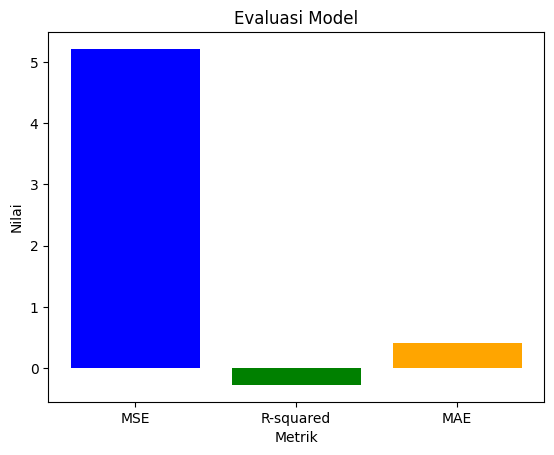

In [ ]:
plt.bar(metrics, values, color=['blue', 'green', 'orange'])
plt.title('Evaluasi Model')
plt.xlabel('Metrik')
plt.ylabel('Nilai')
plt.show()

In [ ]:
# Plotting prediksi untuk setiap fitur (Minimum Temperature, Maximum Temperature, Rainfall)
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

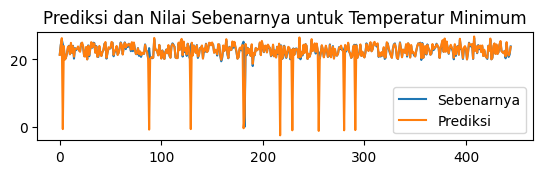

In [ ]:
# Plot temperatur minimum
plt.subplot(3, 1, 1)
plt.plot(y_test.iloc[:, 0].values, label='Sebenarnya')
plt.plot(y_pred[:, 0], label='Prediksi')
plt.title('Prediksi dan Nilai Sebenarnya untuk Temperatur Minimum')
plt.legend()

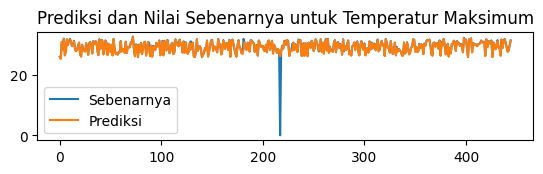

In [ ]:
# Plot temperatur maksimum
plt.subplot(3, 1, 2)
plt.plot(y_test.iloc[:, 1].values, label='Sebenarnya')
plt.plot(y_pred[:, 1], label='Prediksi')
plt.title('Prediksi dan Nilai Sebenarnya untuk Temperatur Maksimum')
plt.legend()


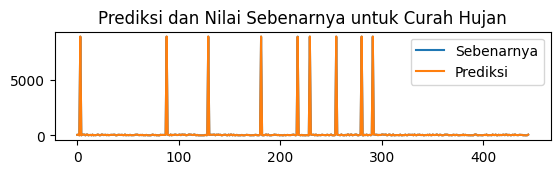

In [ ]:
# Plot curah hujan
plt.subplot(3, 1, 3)
plt.plot(y_test.iloc[:, 2].values, label='Sebenarnya')
plt.plot(y_pred[:, 2], label='Prediksi')
plt.title('Prediksi dan Nilai Sebenarnya untuk Curah Hujan')
plt.legend()

**Save Model**

In [ ]:
tf.saved_model.save(model, 'lstm_model')

### Langkah 1: Install Streamlit dan Localtunnel

In [ ]:
!pip install streamlit -q
!npm install -g localtunnel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 106.0 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
added 22 packages in 2s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋

### Langkah 2: Buat File `app.py` untuk Web App

In [ ]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np

# Load model yang sudah disimpan
model = tf.saved_model.load('lstm_model')
# Fungsi prediksi sederhana untuk model yang di-load
predict_fn = model.signatures['serving_default']

st.title("Aplikasi Prediksi Kondisi Cuaca")
st.write("Masukkan data di bawah ini untuk memprediksi kondisi cuaca.")

# Input dari user
tn = st.number_input("Temperatur Minimum (Tn)", value=20.0)
tx = st.number_input("Temperatur Maksimum (Tx)", value=30.0)
rr = st.number_input("Curah Hujan (RR)", value=5.0)

if st.button("Prediksi"):
    # Siapkan data input (n_timesteps=1, n_features=3)
    input_data = np.array([[tn, tx, rr]], dtype=np.float32)
    input_data_reshaped = input_data.reshape(-1, 1, 3)

    # Konversi ke tensor
    input_tensor = tf.convert_to_tensor(input_data_reshaped)

    # Prediksi (menyesuaikan dengan key output model Keras/TF)
    prediction = predict_fn(input_tensor)
    # Mengambil output pertama (biasanya 'dense_...' atau key pertama)
    output_key = list(prediction.keys())[0]
    result = prediction[output_key].numpy()[0]

    st.subheader("Hasil Prediksi:")
    st.write(f"Prediksi Tn: {result[0]:.2f}")
    st.write(f"Prediksi Tx: {result[1]:.2f}")
    st.write(f"Prediksi RR (Curah Hujan): {result[2]:.2f}")

Writing app.py


### Langkah 3: Jalankan Aplikasi dan Dapatkan Link

1. Jalankan sel di bawah ini.
2. Klik link yang muncul (biasanya berakhiran `.loca.lt`).
3. Jika diminta 'Tunnel Password', masukkan alamat IP publik Colab Anda (jalankan `!curl ipv4.icanhazip.com` untuk melihatnya).

In [ ]:
# Mendapatkan IP untuk password localtunnel
import urllib
print("Password untuk Tunnel:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

# Menjalankan streamlit di background
!streamlit run app.py & npx localtunnel --port 8501

Password untuk Tunnel: 34.177.105.147
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹

your url is: https://social-years-lick.loca.lt
2026-07-05 12:46:43.260 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.177.105.147:8501

2026-07-05 12:50:08.068008: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
  Stopping...
^C
